In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [11]:
import os
print(os.getcwd())
os.listdir()
print(os.path.exists("data"))

c:\Users\HP\Downloads\loan-Repayment-Prediction-main\loan-Repayment-Prediction-main\notebooks
False


In [12]:
df = pd.read_csv("../data/loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Dataset Information

In [16]:
df.shape
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.2 MB


,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


Check Missing Values


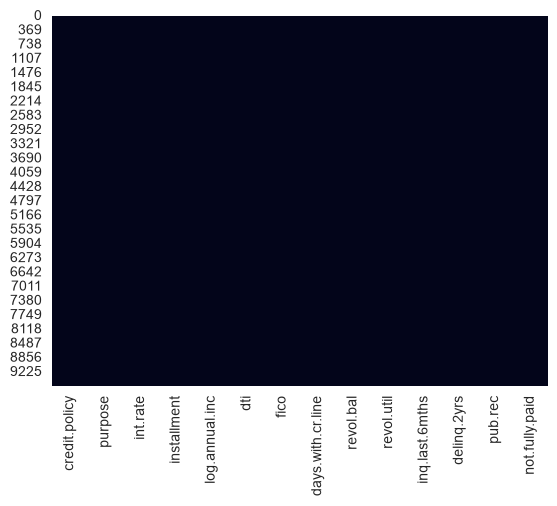

In [17]:
df.isnull().sum()

sns.heatmap(df.isnull(), cbar=False)
plt.show()

### Check Duplicate Rows

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.dtypes

credit.policy          int64
purpose                  str
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

Unique Values in Categorical Columns

In [20]:
df.select_dtypes(include='object').nunique()

for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].value_counts())
    print()

purpose
purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64



C:\Users\HP\AppData\Local\Temp\ipykernel_10324\927082425.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()
C:\Users\HP\AppData\Local\Temp\ipykernel_10324\927082425.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-string

Encode Categorical Columns

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["purpose"] = le.fit_transform(df["purpose"])

Univariate Analysis

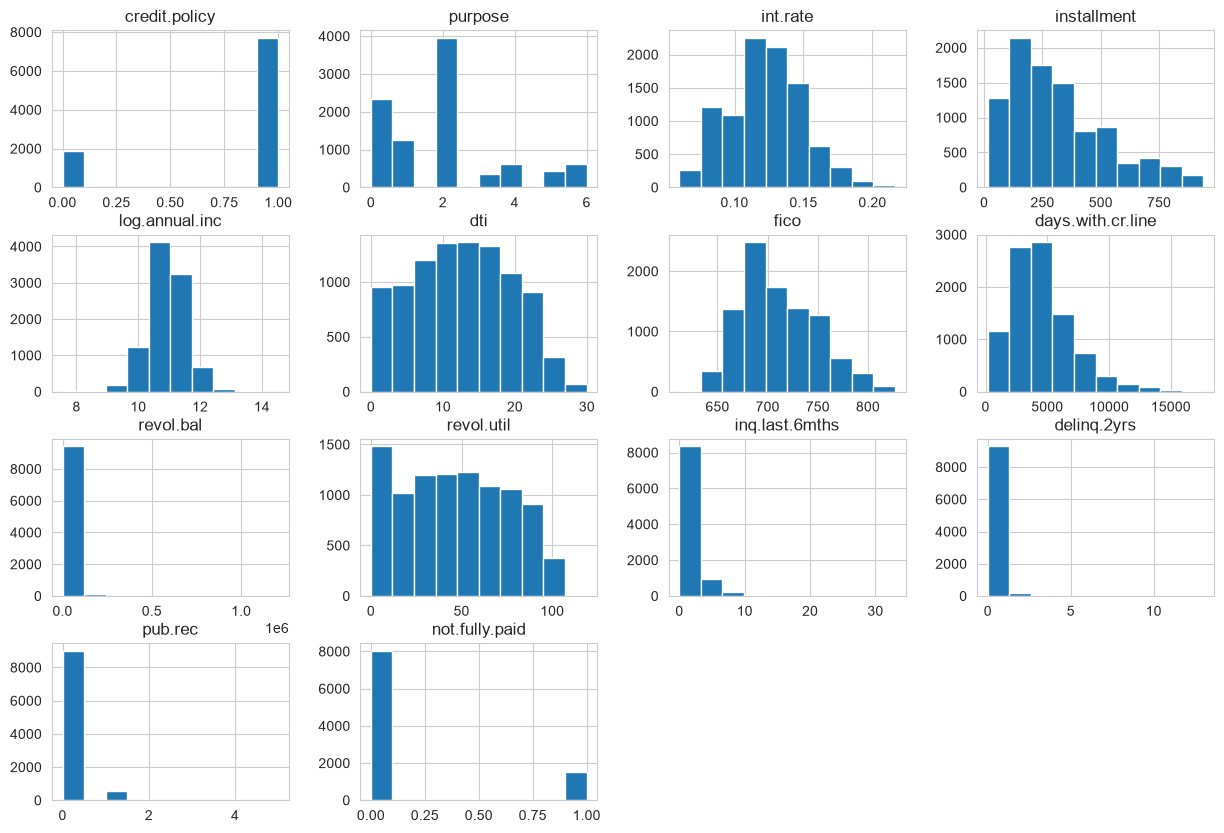

In [22]:
df.hist(figsize=(15,10))
plt.show()

Countplot

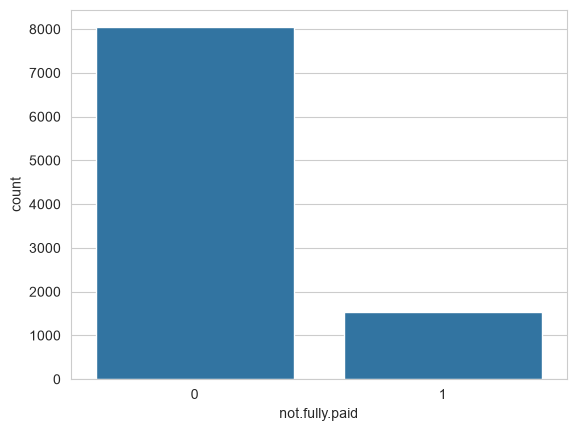

In [23]:
sns.countplot(x='not.fully.paid', data=df)
plt.show()

Outlier Detection

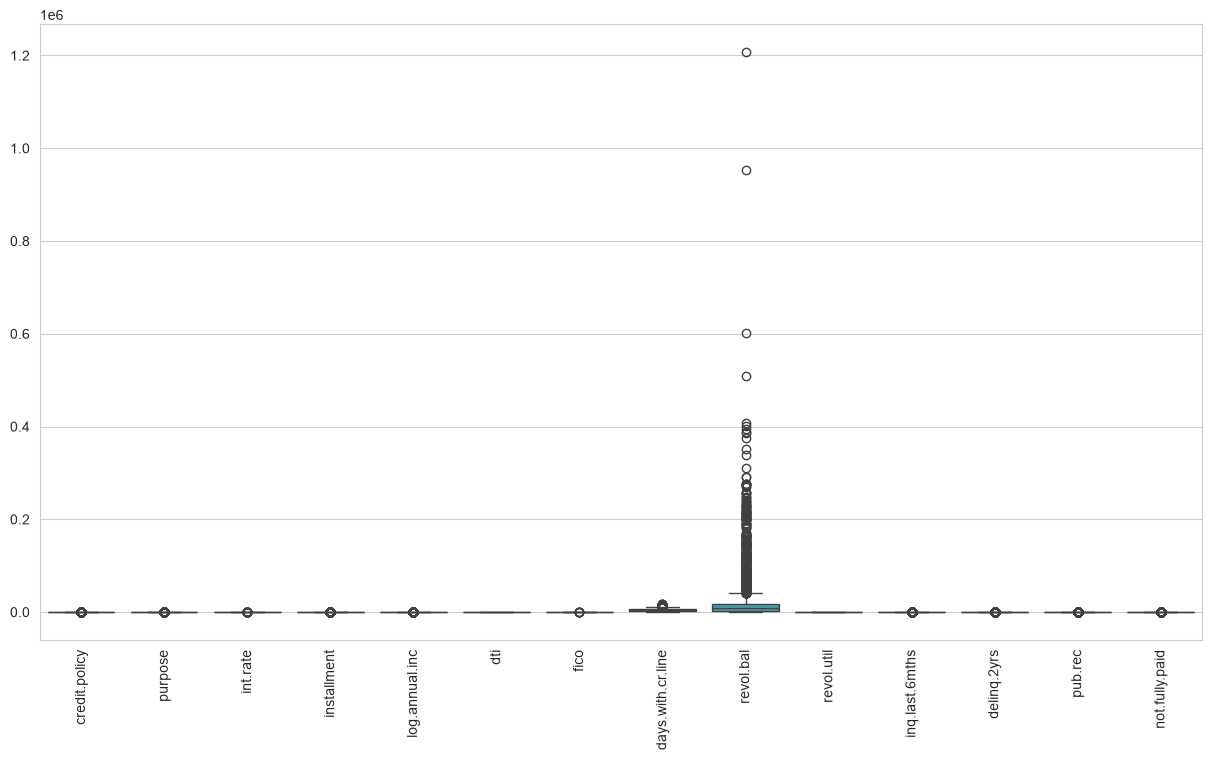

In [24]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Correlation Matrix

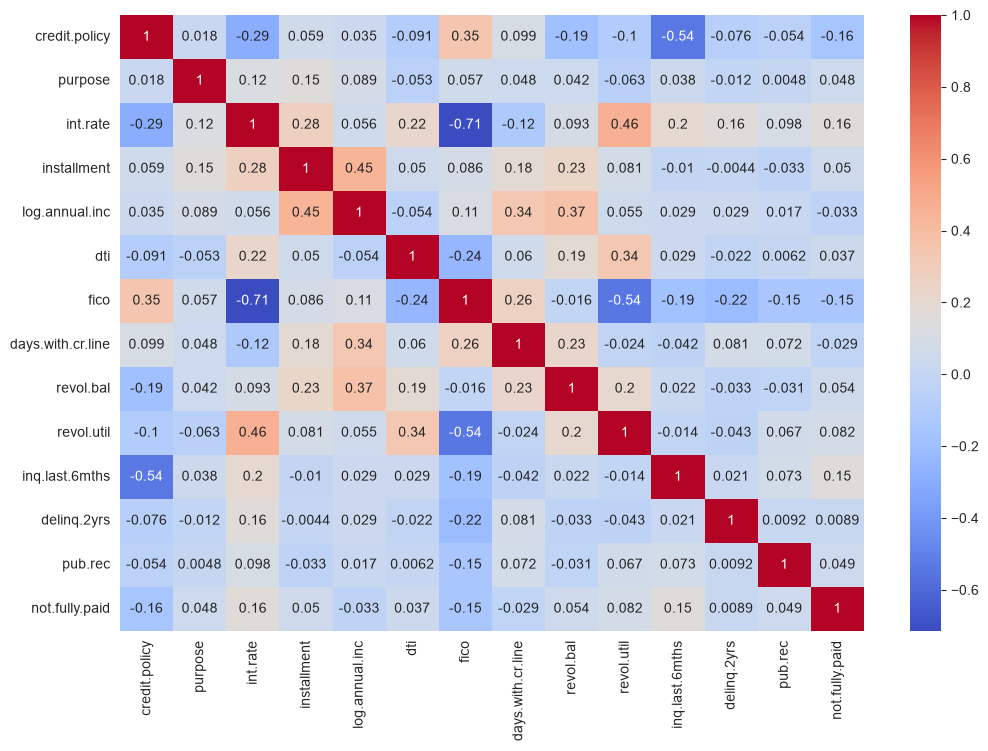

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Pairplot

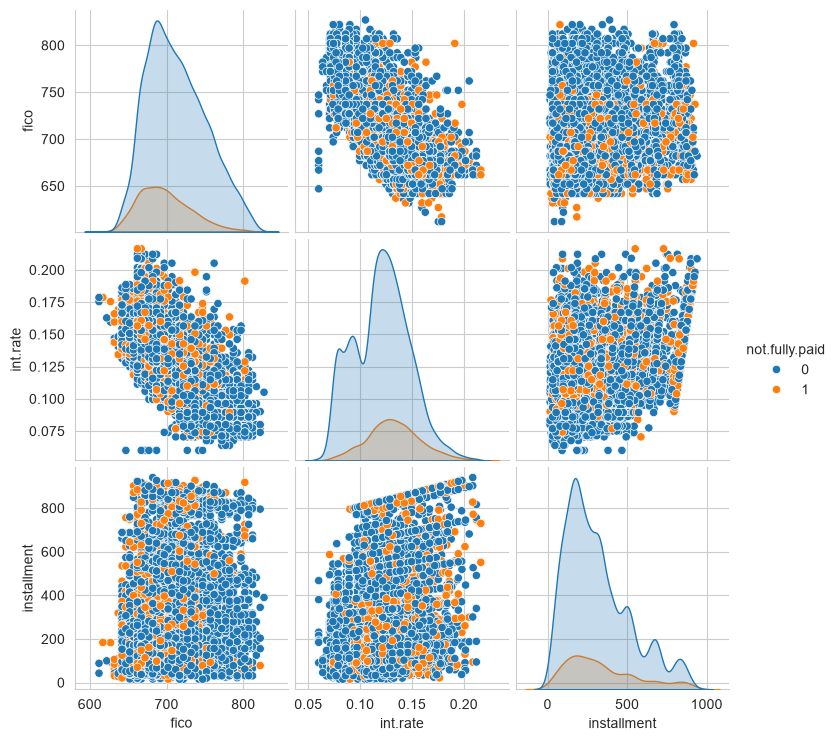

In [26]:
sns.pairplot(df[['fico','int.rate','installment','not.fully.paid']],
             hue='not.fully.paid')
plt.show()

Feature Relationship

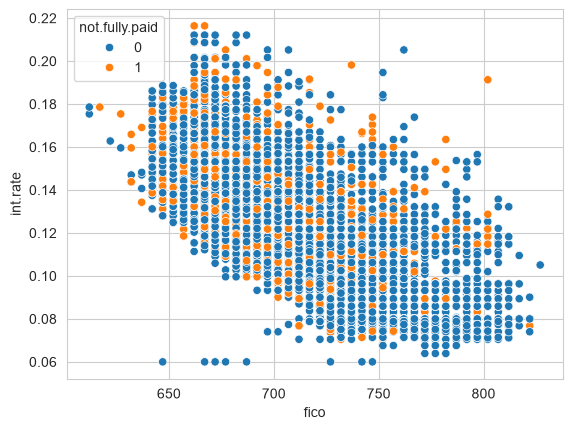

In [27]:
# FICO vs Interest Rate
sns.scatterplot(x='fico',
                y='int.rate',
                hue='not.fully.paid',
                data=df)
plt.show()

Target Variable Distribution

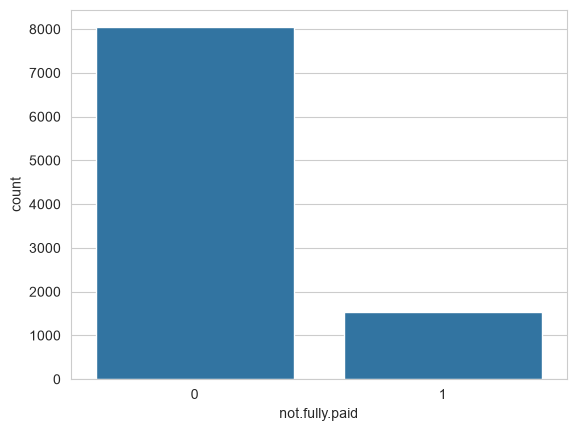

In [28]:
df['not.fully.paid'].value_counts()

sns.countplot(x='not.fully.paid', data=df)
plt.show()

Check class imbalance:

In [29]:
df['not.fully.paid'].value_counts(normalize=True)*100

not.fully.paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64

Feature Importance Before Modeling

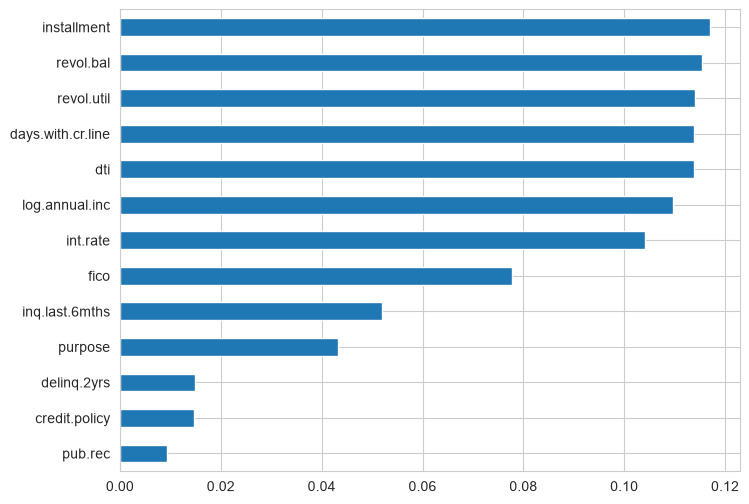

In [30]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.show()